### **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd

import pryngles as pr

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from astropy.visualization import astropy_mpl_style

astropy_mpl_style['font.size'] = 8
astropy_mpl_style['figure.figsize'] = (12,6)

plt.style.use(astropy_mpl_style)

%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Pryngles System**

In [3]:
# Creating Simple System
system = pr.System()

star = system.add(kind = "Star", radius = pr.Consts.rsun/system.ul, 
                  limb_coeffs = [0.65])

planet = system.add(kind = "Planet", parent = star, a = 0.1, 
                    e = 0, radius = pr.Consts.rsaturn/system.ul, m = 0)

ring = system.add(kind = "Ring", parent = planet, 
                  fi = 1.5, fe = 2.5, i = 30*pr.Consts.deg)

In [4]:
# Setting Observer to the Ecplitic Plane
lamda, beta = 0, 0
system.n_obs = pr.Science.direction(lamda, beta)

# Configurating the System
system.initialize_simulation()
system.spangle_system()

### **System Visualization**

(np.int64(0), np.int64(0))

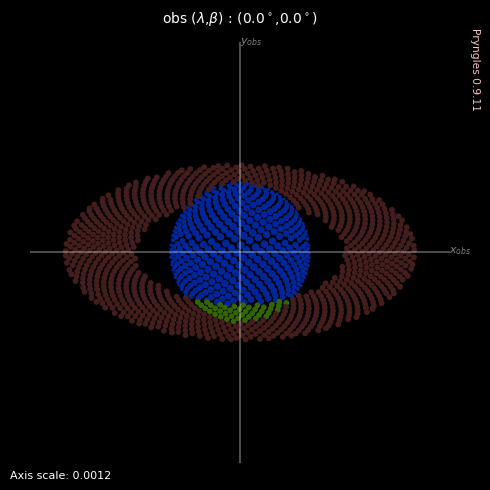

In [190]:
system.integrate_perspective(0)
system.sg.plot2d(exclude = ['Star'])

In [47]:
period = system.sim.orbit.Ps[0]

# Times for integration
ts = np.linspace(-period/2, period/2, 100) # [ut]

# Testing compute_lightcurve Method
system.compute_lightcurve(times = ts,
                          effects = ['polarization'])

Computing Lightcurve : 100%|██████████| 100/100 [03:02<00:00,  1.82s/it]


{'times': array([-0.09934588, -0.0973389 , -0.09533191, -0.09332492, -0.09131793,
        -0.08931095, -0.08730396, -0.08529697, -0.08328998, -0.08128299,
        -0.07927601, -0.07726902, -0.07526203, -0.07325504, -0.07124806,
        -0.06924107, -0.06723408, -0.06522709, -0.06322011, -0.06121312,
        -0.05920613, -0.05719914, -0.05519216, -0.05318517, -0.05117818,
        -0.04917119, -0.04716421, -0.04515722, -0.04315023, -0.04114324,
        -0.03913626, -0.03712927, -0.03512228, -0.03311529, -0.03110831,
        -0.02910132, -0.02709433, -0.02508734, -0.02308036, -0.02107337,
        -0.01906638, -0.01705939, -0.01505241, -0.01304542, -0.01103843,
        -0.00903144, -0.00702446, -0.00501747, -0.00301048, -0.00100349,
         0.00100349,  0.00301048,  0.00501747,  0.00702446,  0.00903144,
         0.01103843,  0.01304542,  0.01505241,  0.01705939,  0.01906638,
         0.02107337,  0.02308036,  0.02508734,  0.02709433,  0.02910132,
         0.03110831,  0.03311529,  0.03512

---

## **RingedPlanet Validation**

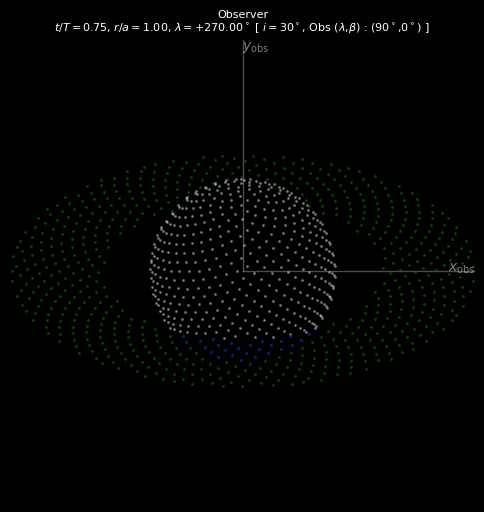

In [6]:
# System to RingedPlanet
system.ensamble_system(lamb = lamda*pr.DEG + np.pi/2, beta = beta*pr.DEG)

system.RP.changeStellarPosition(3*np.pi/2, kepler = False)
system.RP.updateOpticalFactors()
system.RP.plotRingedPlanet(showfig = False, showactive = False)[1]

In [7]:
# One Period
ts = np.linspace(-system.RP.T/2, system.RP.T/2, 100)

# Flux Values for Planet and Ring
reflected_RP = np.zeros((100, 2))
polarization_RP = np.zeros((100, 2))

for i, t in enumerate(ts):

    # Integrating on time domain for RingedPlanet
    system.RP.changeStellarPosition(3*system.RP.T/4 + t, kepler = True)

    # Computing Polarization for RingedPlanet
    system.RP.updateOpticalFactors()
    system.RP.updateReflection()

    # Values for every Time-Step
    reflected_RP[i] = [system.RP.Rip.sum(), system.RP.Rir.sum()]
    polarization_RP[i] = [system.RP.Ptotp, system.RP.Ptotr]

---

## **Plotting Polarization Lightcurve**

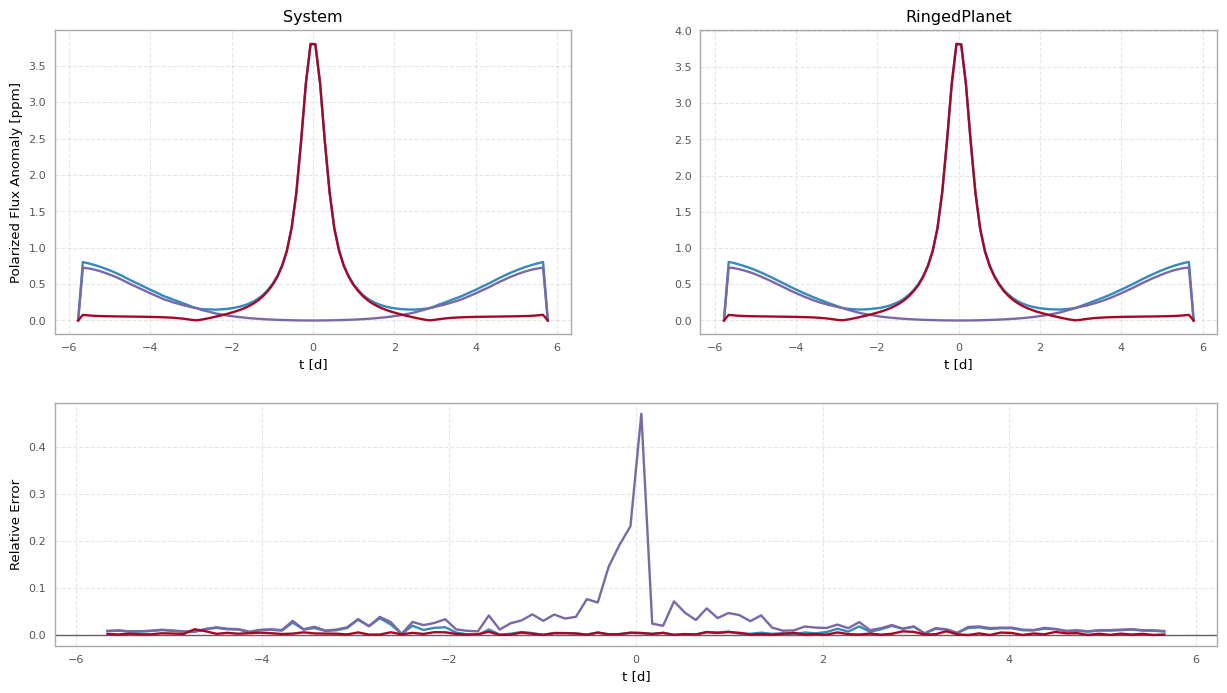

In [ ]:
# --- Figure and GridSpec ---
fig = plt.figure(figsize=(15, 8))
gs = GridSpec(
    nrows=2,
    ncols=2,
    height_ratios=[1, 0.8],
    hspace=0.25,
    wspace=0.25
)

# --- Subplots ---
ax1 = fig.add_subplot(gs[0, 0])   # system
ax2 = fig.add_subplot(gs[0, 1])   # RingedPlanet
ax3 = fig.add_subplot(gs[1, :])   # Error

for ax in (ax1, ax2, ax3):
    ax.tick_params(direction="in", top=True, right=True)
    ax.grid(alpha=0.3, linestyle="--")

# --- System ---
ax1.set_title("System")
ax1.set_ylabel("Polarized Flux Anomaly [ppm]")
ax1.set_xlabel("t [d]")

ax1.plot(ts*system.ut/pr.Consts.days, (system.lightcurve['flux'] - 1)*1e6, label = 'Total', color = 'C0')

ax1.plot(ts*system.ut/pr.Consts.days, system.lightcurve['model'][('Planet','scattering')]*1e6, label = 'Planet', color = 'C1')
ax1.plot(ts*system.ut/pr.Consts.days, system.lightcurve['model'][('Ring','scattering')]*1e6, label = 'Ring', color = 'C2')

# --- RingedPlanet ---
ax2.set_title("RingedPlanet")
ax2.set_xlabel("t [d]")

ax2.plot(ts*system.ut/pr.Consts.days, reflected_RP.sum(axis = 1), label = 'Total', color = 'C0')

ax2.plot(ts*system.ut/pr.Consts.days, reflected_RP[:,0], label = 'Planet', color = 'C1')
ax2.plot(ts*system.ut/pr.Consts.days, reflected_RP[:,1], label = 'Ring', color = 'C2')

# --- Error ---
ax3.set_ylabel("Relative Error")
ax3.set_xlabel("t [d]")
ax3.axhline(0.0, color="k", lw=1, alpha=0.6)

error_total = abs((system.lightcurve['flux'] - 1)*1e6 - reflected_RP.sum(axis = 1))/reflected_RP.sum(axis = 1)

error_planet = abs(system.lightcurve['model'][('Planet','scattering')]*1e6 - reflected_RP[:,0])/reflected_RP[:,0]
error_ring = abs(system.lightcurve['model'][('Ring','scattering')]*1e6 - reflected_RP[:,1])/reflected_RP[:,1]

ax3.plot(ts*system.ut/pr.Consts.days, error_total, label = 'Total', color = 'C0')

ax3.plot(ts*system.ut/pr.Consts.days, error_planet, label = 'Planet', color = 'C1')
ax3.plot(ts*system.ut/pr.Consts.days, error_ring, label = 'Ring', color = 'C2')

plt.tight_layout()


---

## **Degree of Polarization**

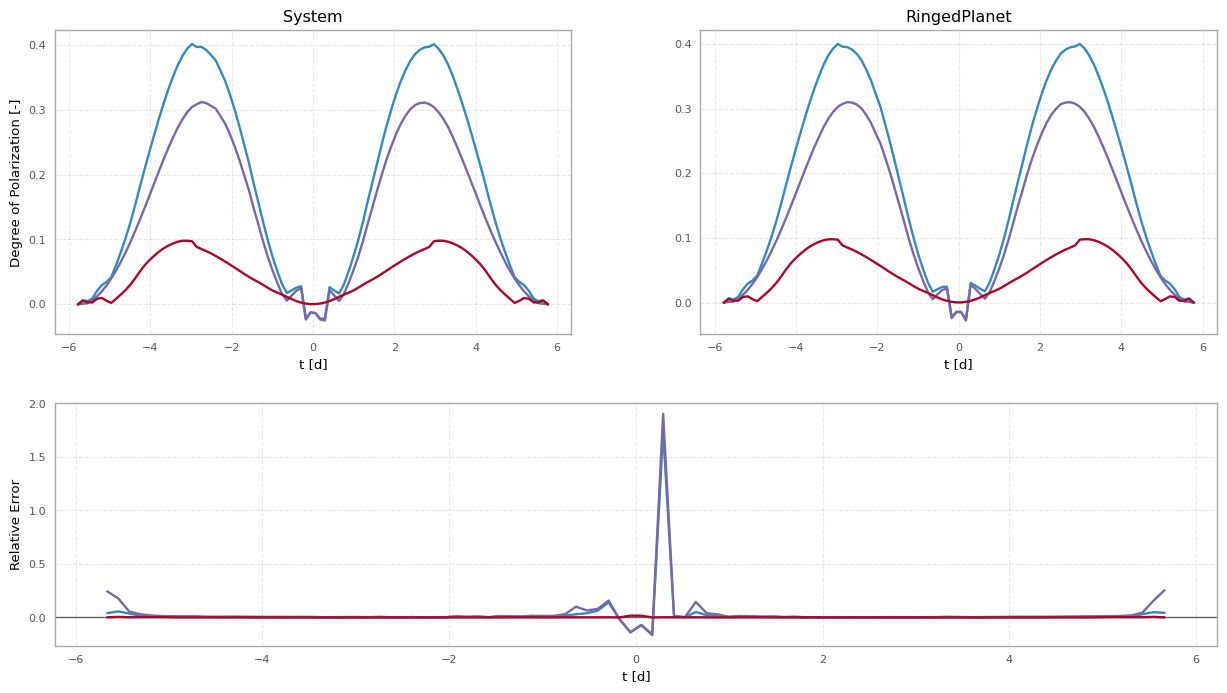

In [80]:
# --- Figure and GridSpec ---
fig = plt.figure(figsize=(15, 8))
gs = GridSpec(
    nrows=2,
    ncols=2,
    height_ratios=[1, 0.8],
    hspace=0.25,
    wspace=0.25
)

# --- Subplots ---
ax1 = fig.add_subplot(gs[0, 0])   # system
ax2 = fig.add_subplot(gs[0, 1])   # RingedPlanet
ax3 = fig.add_subplot(gs[1, :])   # Error

for ax in (ax1, ax2, ax3):
    ax.tick_params(direction="in", top=True, right=True)
    ax.grid(alpha=0.3, linestyle="--")

# --- System ---
ax1.set_title("System")
ax1.set_ylabel("Degree of Polarization [-]")
ax1.set_xlabel("t [d]")

total_DOP_system = system.lightcurve['model'].loc[:,(['Planet', 'Ring'],'polarization')].sum(axis = 1)

ax1.plot(ts*system.ut/pr.Consts.days, total_DOP_system, label = 'Total', color = 'C0')

ax1.plot(ts*system.ut/pr.Consts.days, system.lightcurve['model'][('Planet','polarization')], label = 'Planet', color = 'C1')
ax1.plot(ts*system.ut/pr.Consts.days, system.lightcurve['model'][('Ring','polarization')], label = 'Ring', color = 'C2')

# --- RingedPlanet ---
ax2.set_title("RingedPlanet")
ax2.set_xlabel("t [d]")

ax2.plot(ts*system.ut/pr.Consts.days, polarization_RP.sum(axis = 1), label = 'Total', color = 'C0')

ax2.plot(ts*system.ut/pr.Consts.days, polarization_RP[:,0], label = 'Planet', color = 'C1')
ax2.plot(ts*system.ut/pr.Consts.days,  polarization_RP[:,1], label = 'Ring', color = 'C2')

# --- Error ---
ax3.set_ylabel("Relative Error")
ax3.set_xlabel("t [d]")
ax3.axhline(0.0, color="k", lw=1, alpha=0.6)

error_total = abs(total_DOP_system- polarization_RP.sum(axis = 1))/polarization_RP.sum(axis = 1)

error_planet = abs(system.lightcurve['model'][('Planet','polarization')] - polarization_RP[:,0])/polarization_RP[:,0]
error_ring = abs(system.lightcurve['model'][('Ring','polarization')] - polarization_RP[:,1])/polarization_RP[:,1]

ax3.plot(ts*system.ut/pr.Consts.days, error_total, label = 'Total', color = 'C0')

ax3.plot(ts*system.ut/pr.Consts.days, error_planet, label = 'Planet', color = 'C1')
ax3.plot(ts*system.ut/pr.Consts.days, error_ring, label = 'Ring', color = 'C2')

plt.tight_layout()
